# Step 4: Customer Retention Analysis

## Goal
Measure customer retention and identify churn patterns over time.

## Why this matters
Retention analysis helps quantify how long customers stay active, how many stop purchasing, and where the business may be losing revenue.

## Approach
- SQL for churn definition and retention metrics
- Python for cohort analysis and visualization

## Churn Definition

A customer is considered churned if they have not made a purchase within 30 days of their last transaction.

## Churn Rate

Using this definition, approximately 61.57% of customers are classified as churned.

This suggests a high drop-off rate in customer activity, indicating potential opportunities for retention strategies such as targeted marketing or re-engagement campaigns.

## Customer Lifespan Analysis

Customer lifespan measures the duration between a customer's first and last purchase.

Many customers exhibit a lifespan of 0 days, indicating one-time purchases. However, a subset of customers remains active over extended periods (100–300+ days), suggesting strong repeat purchasing behavior.

This variation highlights the importance of retention strategies to convert one-time buyers into long-term customers.

## Cohort Analysis (Base Table)

Customers are grouped into cohorts based on their first purchase month.

For each cohort, we track how many customers remain active in subsequent months.

This forms the foundation for analyzing retention trends over time.

In [1]:
# Load cohort data

import sqlite3
import pandas as pd

conn = sqlite3.connect("../db/batchbridge.db")

cohort_df = pd.read_sql_query("""
WITH cohort AS (
    SELECT
        CustomerID,
        strftime('%Y-%m', MIN(InvoiceDate)) AS cohort_month
    FROM ecommerce_cleaned
    GROUP BY CustomerID
),
transactions AS (
    SELECT
        CustomerID,
        strftime('%Y-%m', InvoiceDate) AS txn_month
    FROM ecommerce_cleaned
)
SELECT
    c.cohort_month,
    t.txn_month,
    COUNT(DISTINCT t.CustomerID) AS active_customers
FROM cohort c
JOIN transactions t
    ON c.CustomerID = t.CustomerID
GROUP BY c.cohort_month, t.txn_month
ORDER BY c.cohort_month, t.txn_month;
""", conn)

cohort_df.head()



,cohort_month,txn_month,active_customers
0,2010-12,2010-12,885
1,2010-12,2011-01,324
2,2010-12,2011-02,286
3,2010-12,2011-03,340
4,2010-12,2011-04,321


In [2]:
# Convert dates

cohort_df['cohort_month'] = pd.to_datetime(cohort_df['cohort_month'])
cohort_df['txn_month'] = pd.to_datetime(cohort_df['txn_month'])

In [3]:
# Create cohort index

cohort_df['cohort_index'] = (
    (cohort_df['txn_month'].dt.year - cohort_df['cohort_month'].dt.year) * 12 +
    (cohort_df['txn_month'].dt.month - cohort_df['cohort_month'].dt.month)
)

In [4]:
# Pivot 

cohort_pivot = cohort_df.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='active_customers'
)

cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN


In [5]:
# Retention %

retention_matrix = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0)

retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


In [7]:
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')

retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


## Retention Matrix

The retention matrix shows the percentage of customers from each cohort who remain active over time.

Each row represents a cohort (first purchase month), and each column represents months since acquisition.

This allows us to evaluate customer retention and identify how quickly customers drop off after their initial purchase.

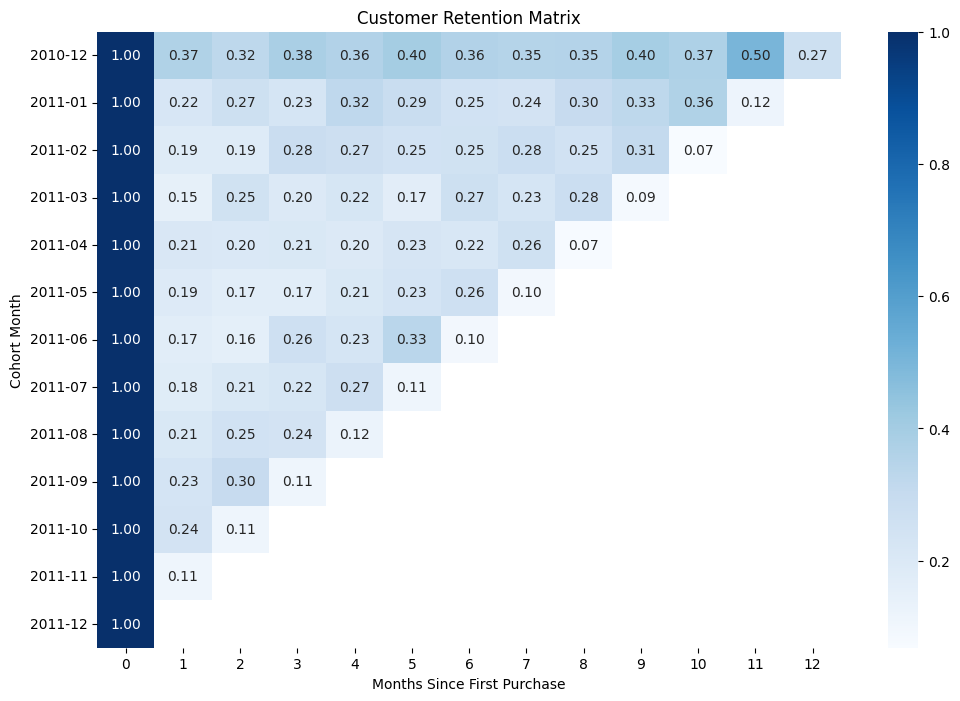

In [8]:
# Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Customer Retention Matrix")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")

plt.show()

## Retention Heatmap

The heatmap visualizes customer retention across cohorts over time.

Darker colors indicate higher retention, while lighter colors indicate customer drop-off.

The chart shows that retention declines significantly after the first month, suggesting that many customers do not return after their initial purchase. However, a smaller group of customers continues to engage over time, contributing to long-term revenue.

This highlights an opportunity to improve early-stage retention through targeted engagement strategies.